<a href="https://colab.research.google.com/github/krkoki/-TIL-Python-Study/blob/master/HeartJisikIn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#네이버 지식인 '여친선물' 크롤링 및 워드클라우드화

In [ ]:
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
!rm -rf ~/.cache/matplotlib > /dev/null

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['font.family'] = 'NanumBarunGothic'

In [ ]:
#konlpy 설치
!pip install konlpy > /dev/null

In [ ]:
!apt-get update > /dev/null 2>&1
!pip install selenium > /dev/null 2>&1
!apt install chromium-chromedriver > /dev/null 2>&1

In [ ]:
import requests
import pandas as pd
import time
import folium
import json
import math
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from urllib.parse import quote
from tqdm.notebook import tqdm
from bs4 import BeautifulSoup

In [ ]:
options = webdriver.ChromeOptions()
options.add_argument('--headless') # 화면 출력 x
options.add_argument('--no-sandbox') # ?
options.add_argument('--single-process')
options.add_argument('--disable-dev-shm-usage') # /deb/shm 디렉토리를 사용하지 않음 공유메모리를 담당
driver = webdriver.Chrome('chromedriver', options=options)

In [ ]:
base_url = 'https://kin.naver.com/search/list.naver?query='
url = base_url + quote('여친선물')
driver.get(url)

In [ ]:
answer_list = []
for page in range(1, 11):
  print('page', page)
  url = f"{base_url}{quote('여친선물')}&page={page}"
  driver.get(url)
  time.sleep(2)

  html = driver.page_source
  soup = BeautifulSoup(html, 'html.parser')
  lis = soup.select('.basic1 > li')

  for li in lis:
    sub_url = li.select_one('a._searchListTitleAnchor')['href']
    driver.get(sub_url)
    time.sleep(2)

    count = int(driver.find_element(By.CSS_SELECTOR, '._answerCount.num').text)
    answer_page = (count - 1) // 5

    for i in range(answer_page):
      driver.find_element(By.ID, 'nextPageButton').click()
      time.sleep(2)
    html = driver.page_source
    soup = BeautifulSoup(html, 'html.parser')
    divs = soup.select('div.answer-content__item._contentWrap._answer')
    
    for div in divs:
      ps = div.select('p.se-text-paragraph')
      for p in ps:
        text = p.get_text()
        if text == '' or text == '\u200b':
          continue
        answer_list.append(text)
    driver.back()
    time.sleep(2)

page 1
page 2
page 3
page 4
page 5
page 6
page 7
page 8
page 9
page 10


In [ ]:
len(answer_list)

3952

In [ ]:
# 사용끝난 드라이버 닫기
driver.close()

In [ ]:
with open('new_gift.txt', 'w', encoding = 'utf-8') as fp:
  for answer in answer_list:
    fp.write(answer + '\n')

# 여친선물 워드클라우드

In [ ]:
from konlpy.tag import Okt, Kkma, Komoran
from wordcloud import WordCloud
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
okt = Okt()

In [ ]:
with open('new_gift.txt') as file:
  text = file.read()

In [ ]:
# 명사만 추출
tokens = okt.nouns(text)

In [ ]:
tokens

['풀잎',
 '문화센터',
 '카페',
 '십자수',
 '도안',
 '사용',
 '그림',
 '도안',
 '남친',
 '십자수',
 '것',
 '여자친구',
 '분',
 '생일',
 '선물',
 '제품',
 '고민',
 '제',
 '실제',
 '남친',
 '일주일',
 '사랑',
 '영화',
 '교환일기',
 '추천',
 '여친',
 '번갈아',
 '가면',
 '질문',
 '답',
 '수',
 '교환일기',
 '커플',
 '문답',
 '컷',
 '앨범',
 '번',
 '앞쪽',
 '몇',
 '장',
 '정도',
 '사진',
 '질문',
 '답',
 '나머진',
 '나가시',
 '감동',
 '수',
 '선물',
 '아침',
 '주문',
 '그',
 '담날',
 '바로',
 '거',
 '진짜',
 '강',
 '추강',
 '추',
 '또',
 '강',
 '혹시',
 '링크',
 '채택',
 '목걸이',
 '크로스',
 '가요',
 '그냥',
 '분위기',
 '음식점',
 '생일',
 '축하',
 '해',
 '팔찌',
 '쇼핑몰',
 '후기',
 '팔찌',
 '거',
 '대부분',
 '실패',
 '안해',
 '좀',
 '목걸이',
 '선물',
 '퀴스퀴스',
 '탄생석',
 '목걸이',
 '추천',
 '탄생석',
 '셋팅되어',
 '나름',
 '더욱더',
 '의미',
 '선물',
 '생각',
 '여자친구',
 '선물',
 '목걸이',
 '추천',
 '비비안',
 '웨스트우드',
 '목걸이',
 '실버',
 '재질',
 '핑크',
 '컬러',
 '하트',
 '팬던트',
 '구성',
 '정장',
 '얼룩',
 '매치',
 '단계',
 '길이',
 '조절',
 '스타',
 '일링',
 '시기',
 '줗',
 '추천',
 '참고',
 '모두',
 '배',
 '적립금',
 '가정',
 '달',
 '핫특',
 '상품',
 '악세사리',
 '선물',
 '가요',
 '준',
 '목걸이',
 '가지',
 '추천',
 '가성',
 '비',
 '다이아',
 '로티',
 '하트',
 '

In [ ]:
# 영문자, 숫자, 부호 제거하기
import re
tokens = [re.sub('[^가-힣]', '', token) for token in tokens]

In [ ]:
import nltk
nltk.download('punkt') # 코랩에서는 매번 다운로드 해야됨.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

* 다음의 두과정을 반복해서 불용어를 정리

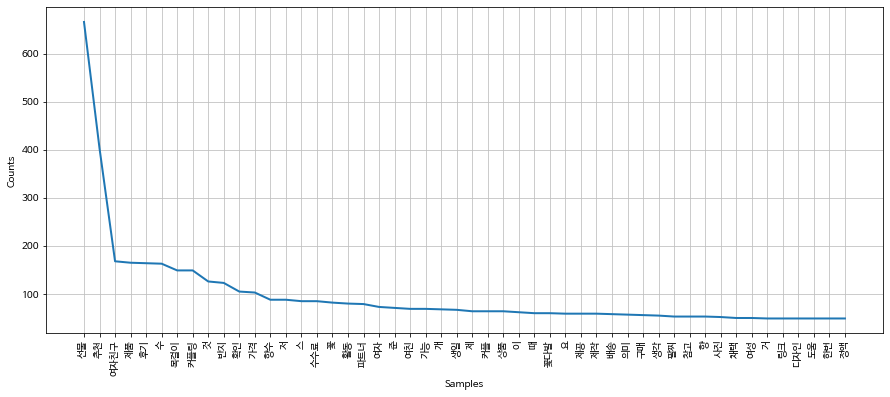

In [ ]:
gift = nltk.Text(tokens, name = '여친선물')
plt.figure(figsize = (15, 6))
gift.plot(50)
plt.show()

In [ ]:
stoptext = '''
    선물 추천 여자친구 제품 후기 수 것 확인 가격 저 스 수수료 활동 파트너 여자 준 여친 가능 개 생일 제 커플 상품 이 때 요 제공 제작 배송 의미 구매 생각 참고 채택 여성 거 링크 디자인 도움 한번 정액 더 브랜드 네이버 가지 인기 답변 동해 하트 친구 분 
    주문 가성 비 고급 마감 세트 위 기념일 고민 사용 날 쿠팡 날 핸드 변경 질문 부담 정말 안쪽 남자 감동 사이트 요즘 중 동해 용 그냥 남녀 판매 직접 이래 블로그 포장 각인 처리 이니셜 바로 구성 가장 끗 드라마 협찬 맞춤 정도 너 사이즈 스토어 무광 일환 여기
    아래 곳 미만 로 심플 유광 이벤트 할인 취향 기부 조금 이면 시 그 순 다음 다른 포스팅 제일 해 아이템 팽이 로티 인테리어 크리스마스 바로가기 순위 핑크 에어 도 사람 보시 자 무료 남자친구 데이트 지금 평 무난 보통 몇개 복부 
    전 더욱 일정 부모님 저희 아주 끈 듯 좀 느낌 감성 템 끌 디 퓨져 옵션 혹시 실제'''

In [ ]:
stop_words = stoptext.split()
tokens = [token for token in tokens if token not in stop_words]

In [ ]:
gift = nltk.Text(tokens, name = '여친선물')
plt.figure(figsize = (25, 12))
gift.plot(50)
plt.show()

# 워드클라우드 그리기

In [ ]:
from PIL import Image

In [ ]:
data = gift.vocab().most_common(300)

In [ ]:
wc = WordCloud(font_path = font_path, background_color = 'white', relative_scaling = 0.2).generate_from_frequencies(dict(data))

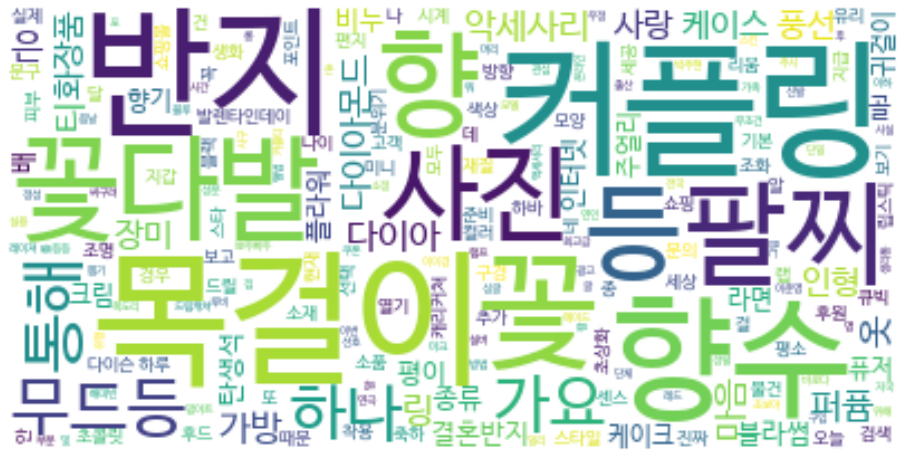

In [ ]:
plt.figure(figsize = (16, 9))
plt.imshow(wc, interpolation = 'bilinear')
plt.axis('off')
plt.show()

- 하트 그림으로 표시

In [ ]:
mask = np.array(Image.open('heart.jpg'))

In [ ]:
from wordcloud import ImageColorGenerator
image_colors = ImageColorGenerator(mask)

In [ ]:
wc = WordCloud(font_path = font_path, background_color = 'white', relative_scaling = 0.2, mask = mask, min_font_size = 1, max_font_size = 120).generate_from_frequencies(dict(data))

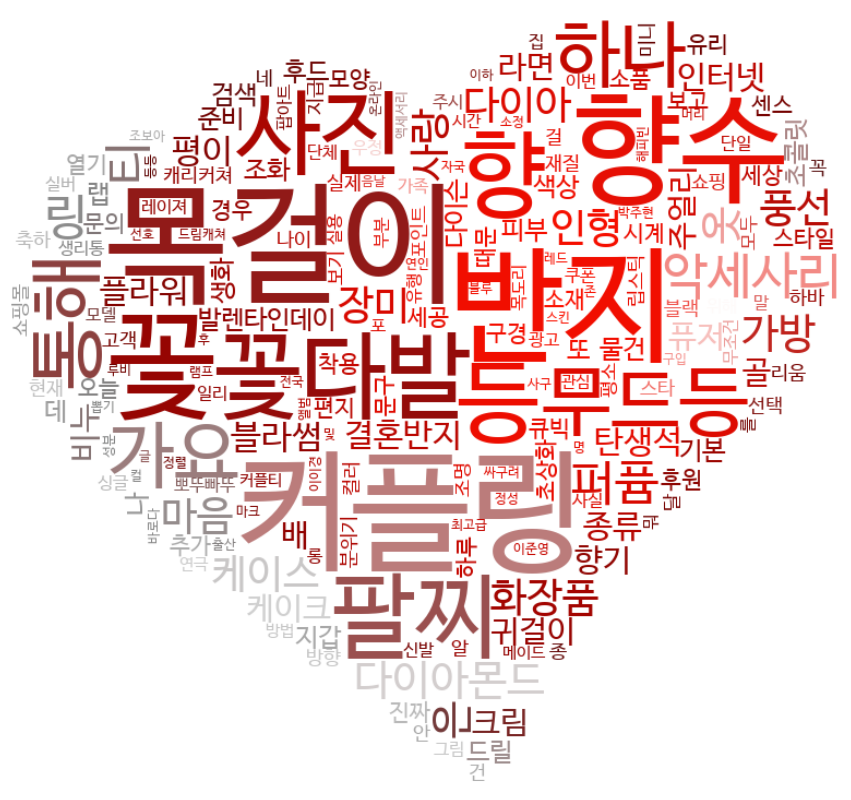

In [ ]:
plt.figure(figsize = (15, 15))
plt.imshow(wc.recolor(color_func = image_colors), interpolation = 'bilinear')
plt.axis('off')
plt.show()